# "ZDRAVOTNÍ KARTA OBCE"

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from patsy import cr
import plotly.graph_objects as go

In [35]:
df = pd.read_csv('../data/cities_with_all_data.csv')

# Odstranit duplicitní sloupce (ponechat první výskyt)
df = df.loc[:, ~df.columns.duplicated()]

all_vars = df.columns.tolist()
print(all_vars)
vars_to_use = ["Cislo_obce", "Nazev_obce_prijmy", "DPFO_zavisla_c", "DPFO_zavisla_h", "DPPO", "Total",
               "age_15_64_men", "age_15_64_women", "Okres_y", "Index_stari", "Lon_x", "Lat_x", "Vzdalenost_km", "Kod_Okresu"]
df = df[vars_to_use]

['Cislo_obce', 'Nazev_obce_prijmy', 'DPH', 'DNV', 'DPPO', 'DPFO', 'DPFO_srazkou', 'DPFO_zavisla_c', 'DPFO_zavisla_h', 'Lat_x', 'Lon_x', 'Okres_x', 'Nazev_obce', 'Total', 'Men', 'Women', 'avg_age', 'avg_age_Men', 'avg_age_Women', 'Country', 'Lat_y', 'Lon_y', 'Kraj', 'Nejblizsi_nemocnice', 'Vzdalenost_km', 'Okres_y', 'Obec', 'age_0_14_total', 'age_0_14_men', 'age_0_14_women', 'age_15_64_total', 'age_15_64_men', 'age_15_64_women', 'age_65_plus_total', 'age_65_plus_men', 'age_65_plus_women', 'Prumerny_vek_celkem', 'Prumerny_vek_muzi', 'Prumerny_vek_zeny', 'Index_stari', 'Kod_Okresu', 'key']


In [36]:
# Zkontrolujme duplicitní sloupce v původních datech
print("=== Kontrola duplicitních sloupců ===")
print(f"Celkem sloupců: {len(df.columns)}")
print(f"Unikátních názvů: {len(df.columns.unique())}")

# Najdeme duplicity
duplicates = df.columns[df.columns.duplicated()].tolist()
if duplicates:
    print(f"\n⚠️ Duplicitní sloupce: {duplicates}")
    
    # Spočítáme kolikrát se každý vyskytuje
    from collections import Counter
    counts = Counter(df.columns)
    for col, count in counts.items():
        if count > 1:
            print(f"  {col}: {count}x")
else:
    print("✓ Žádné duplicitní sloupce")

=== Kontrola duplicitních sloupců ===
Celkem sloupců: 14
Unikátních názvů: 14
✓ Žádné duplicitní sloupce


In [37]:
#normalize
df["DPFO_zavisla_norm"] = (df["DPFO_zavisla_c"] + df["DPFO_zavisla_h"])/df["Total"]
#drop columns
df = df.drop(columns=["DPFO_zavisla_c" ,"DPFO_zavisla_h"])

#make okres categorical
df["Okres_y"] = df["Okres_y"].astype('category')

# drop rows with non-numeric Index_stari
df = df[pd.to_numeric(
    df["Index_stari"], errors='coerce').notnull()]

# convert to float
df["Index_stari"] = df["Index_stari"].astype(float)

df["Total_log"] = np.log1p(df["Total"])
df["Index_stari_log"] =df["Index_stari"].apply(lambda x: np.log1p(x) if x >= 0 else x)

In [38]:

crop_size = 0.05
#throw 1 and 99 percentiles away based on total
df = df[(df["Total"] > df["Total"].quantile(crop_size)) & (df["Total"] < df["Total"].quantile(1-crop_size))]
#same for Index_stari
df = df[(df["Index_stari"] > df["Index_stari"].quantile(crop_size)) & (df["Index_stari"] < df["Index_stari"].quantile(1-crop_size))]
#same DPFO_zavisla_norm
df = df[(df["DPFO_zavisla_norm"] > df["DPFO_zavisla_norm"].quantile(crop_size)) & (df["DPFO_zavisla_norm"] < df["DPFO_zavisla_norm"].quantile(1- crop_size))]

In [39]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
import matplotlib.pyplot as plt

Number of rows after cleaning: 4536
TEST LINEARITY


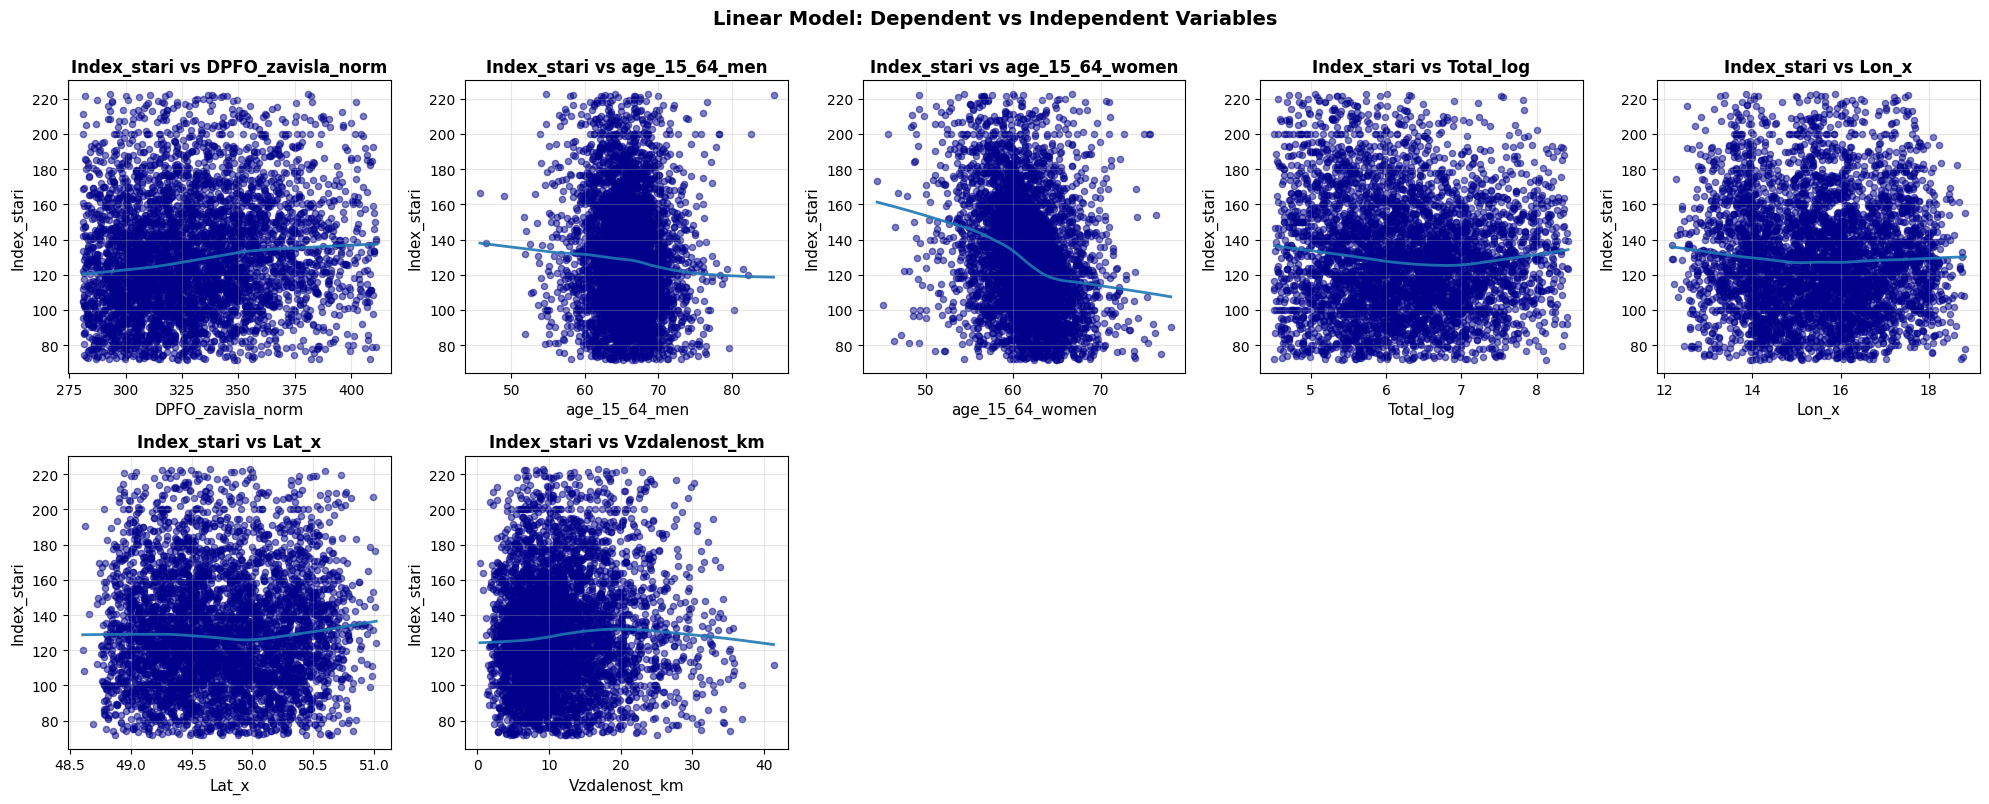

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



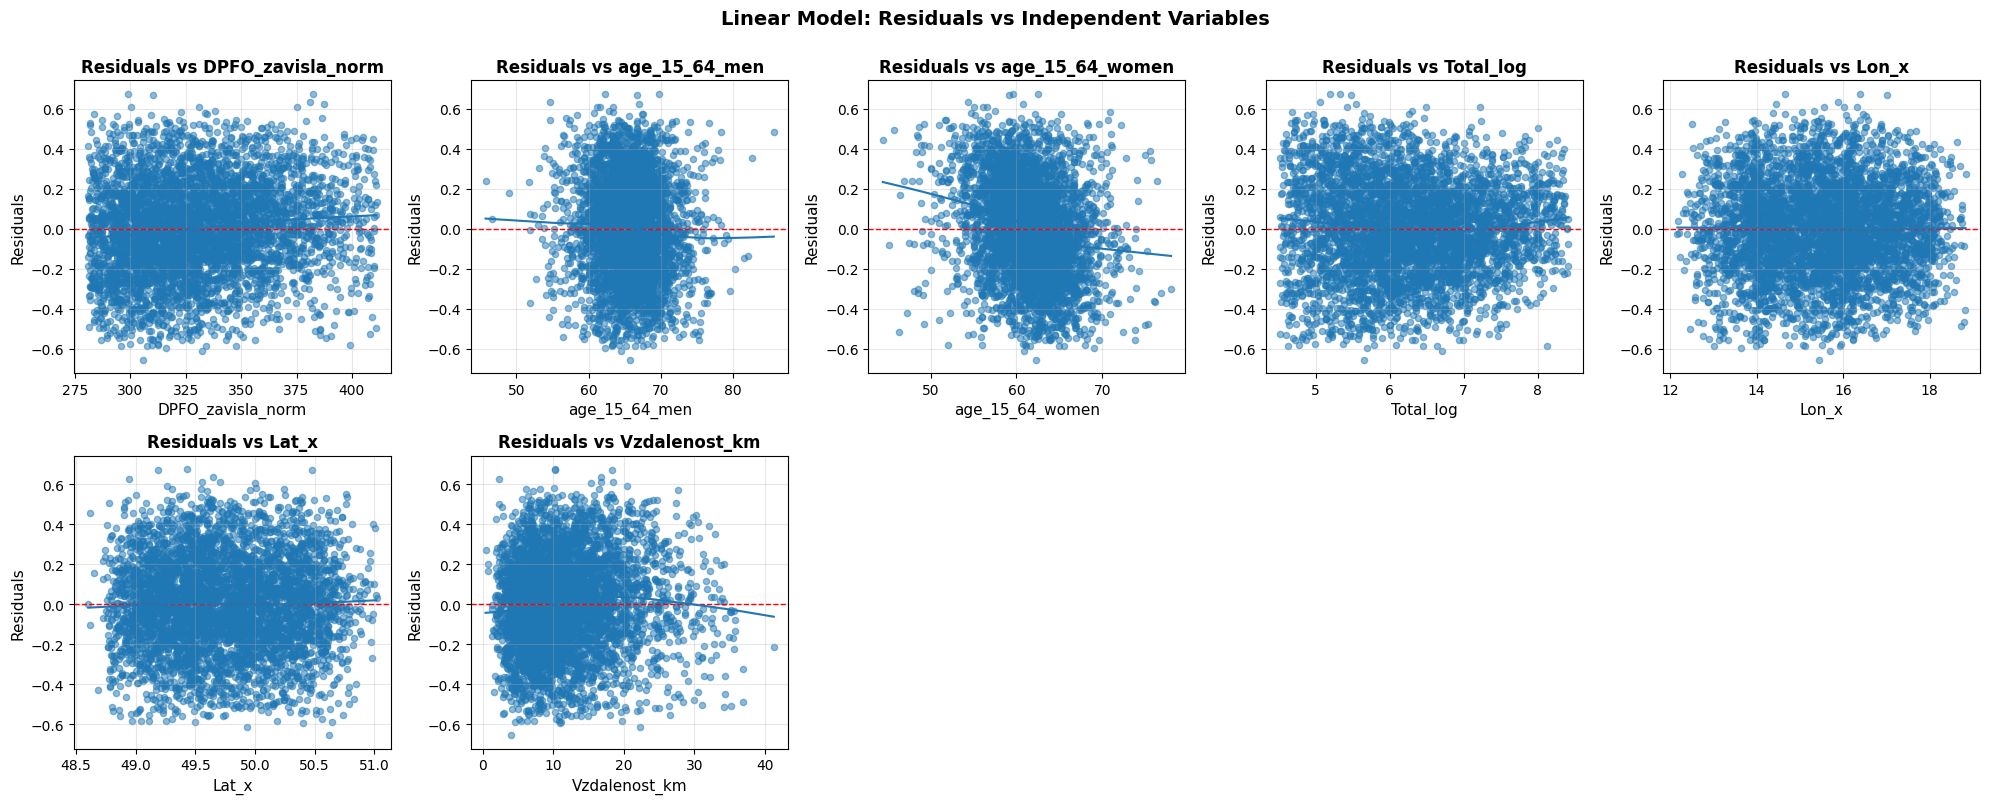

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Linear Model: 0.000674 (LM stat=120.517)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Linear Model: 2.038
Ljung–Box test results for Linear Model (lags [10, 20, 40]):
      lb_stat  lb_pvalue
10   9.413664   0.493346
20  14.280085   0.816016
40  40.827964   0.433908


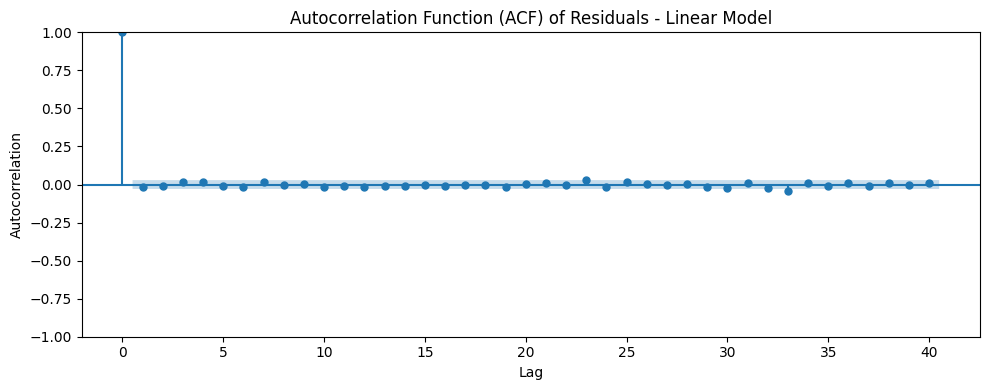

------------------------------------------------
TEST NORMALITY OF ERRORS


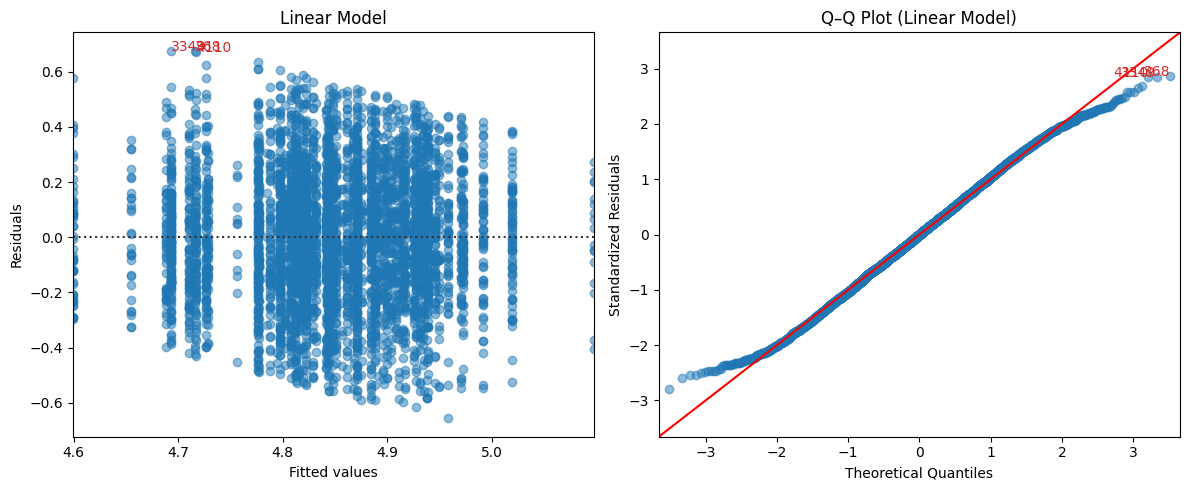

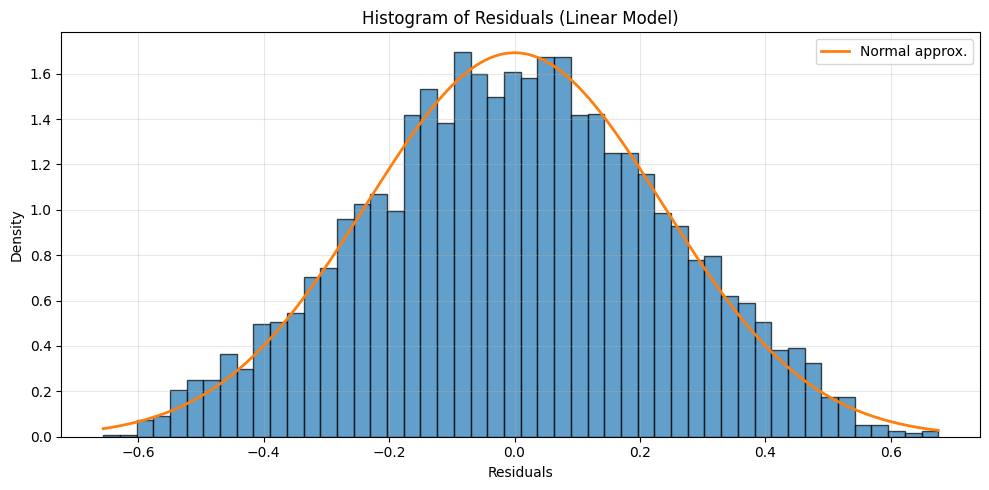

Shapiro–Wilk test for Linear Model: W=0.9967, p-value=1.672e-08
------------------------------------------------
TEST MULTICOLLINEARITY


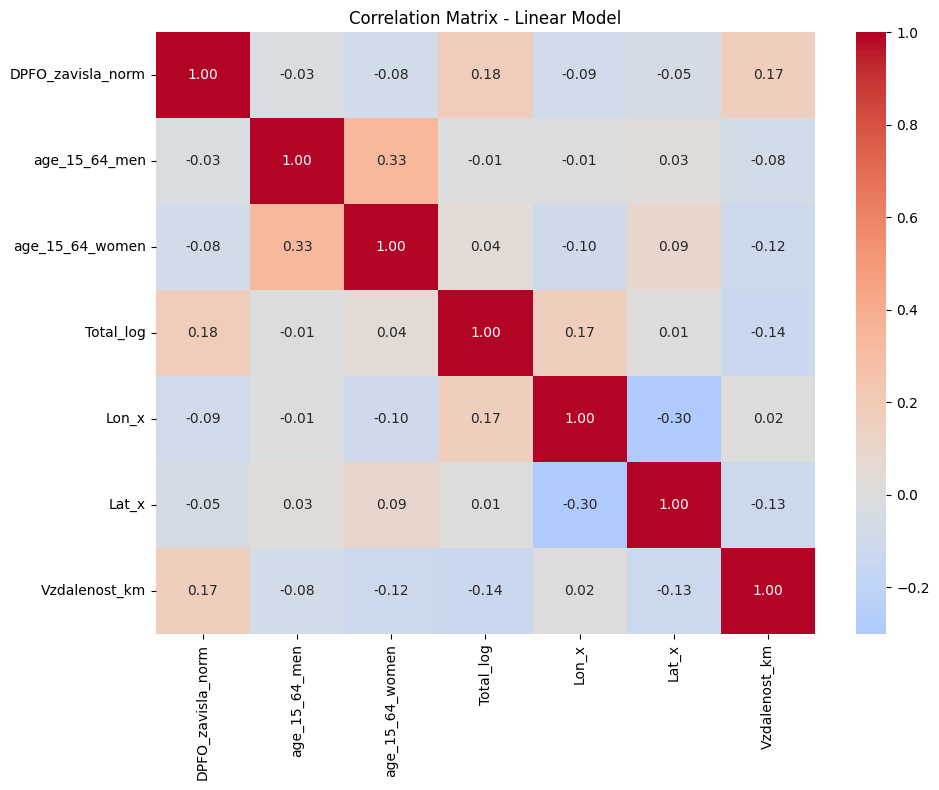

Variance Inflation Factor (VIF):
                                Features  VIF Factor
21           C(Okres_y)[T.Okres Karviná]        1.07
38     C(Okres_y)[T.Okres Ostrava-město]        1.13
42       C(Okres_y)[T.Okres Plzeň-město]        1.17
31              C(Okres_y)[T.Okres Most]        1.22
16           C(Okres_y)[T.Okres Jeseník]        1.24
..                                   ...         ...
67            C(Okres_y)[T.Okres Znojmo]        2.46
62            C(Okres_y)[T.Okres Třebíč]        2.72
74  C(Okres_y)[T.Okres Žďár nad Sázavou]        2.85
3        C(Okres_y)[T.Okres Brno-venkov]        2.93
0                              Intercept       64.80

[75 rows x 2 columns]
------------------------------------------------


In [ ]:
from lin_reg_utils import perform_all_tests

# Separate categorical and numeric features
numeric_features = ["DPFO_zavisla_norm", "age_15_64_men", "age_15_64_women", "Total_log", "Lon_x", "Lat_x", "Vzdalenost_km"]
categorical_features = ["Okres_y"]

# Clean the dataframe first
final_df = df.dropna(subset=numeric_features + categorical_features + ['Index_stari']).copy()

# Odstranit duplicitní sloupce i z final_df (pro jistotu)
final_df = final_df.loc[:, ~final_df.columns.duplicated()]


#num rows
print(f"Number of rows after cleaning: {final_df.shape[0]}")


# Convert categorical variable to string (patsy C() works better with strings)
final_df['Okres_y'] = final_df['Okres_y'].astype(str)

# Build formula with C() wrapper for categorical variables
formula_parts = [f"C({cat})" for cat in categorical_features] + numeric_features
string_x = ' + '.join(formula_parts)

model = smf.ols('Index_stari_log ~ ' + string_x, data=final_df).fit()

# For perform_all_tests, use only numeric features
perform_all_tests(model, final_df, numeric_features, 'Linear Model', y_col='Index_stari')

Looking at assumptions, we see that the model violates some of them:
1) Linearity - <span style="color:Green;">Holds</span>
    - there is a linear trend 
2) Independence of errors - <span style="color:green;">Holds</span> 
    - based on Durbin-Watson test, Ljung-Box test and ACF plot of residuals we can say that there is no autocorrelation
3) Normality of residuals - <span style="color:green;">Holds</span>
    - based on Q-Q plot, histogram we can say that the residuals are now normally distributed 
    - Shapiro-Wilk test is in this case not reliable due to large sample size (https://statisticsbyjim.com/glossary/shapiro-wilk-normality-test/)
4) Homoscedasticity - <span style="color:red;">Violates</span>
    - based on Breusch-Pagan test there is Heteroscedacity (p-value is < 0.05)
5) Absence of multicollinearity - <span style="color:Green;">Holds</span>
    - there is only one feature in the model so there is no multicollinearity

In [41]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Index_stari_log   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     7.128
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           6.08e-65
Time:                        17:58:50   Log-Likelihood:                 117.73
No. Observations:                4536   AIC:                            -85.46
Df Residuals:                    4461   BIC:                             396.0
Df Model:                          74                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

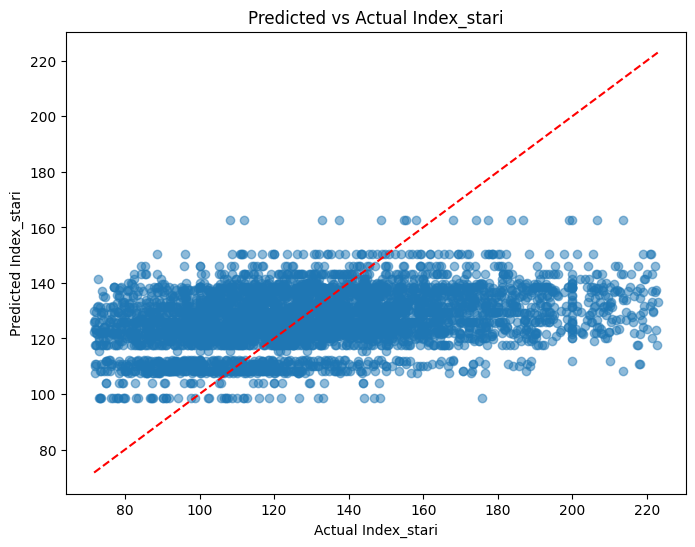

In [42]:
predictions = model.predict(final_df)
predictions = np.expm1(predictions)  # inverse of log1p
#plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(final_df['Index_stari'], predictions, alpha=0.5)
plt.plot([final_df['Index_stari'].min(), final_df['Index_stari'].max()],
         [final_df['Index_stari'].min(), final_df['Index_stari'].max()], 'r--')
plt.xlabel('Actual Index_stari')
plt.ylabel('Predicted Index_stari')
plt.title('Predicted vs Actual Index_stari')
plt.show()

Problem with Heteroscedacity can be solved by using robust error functions instead of ordinary least squares.

TEST LINEARITY


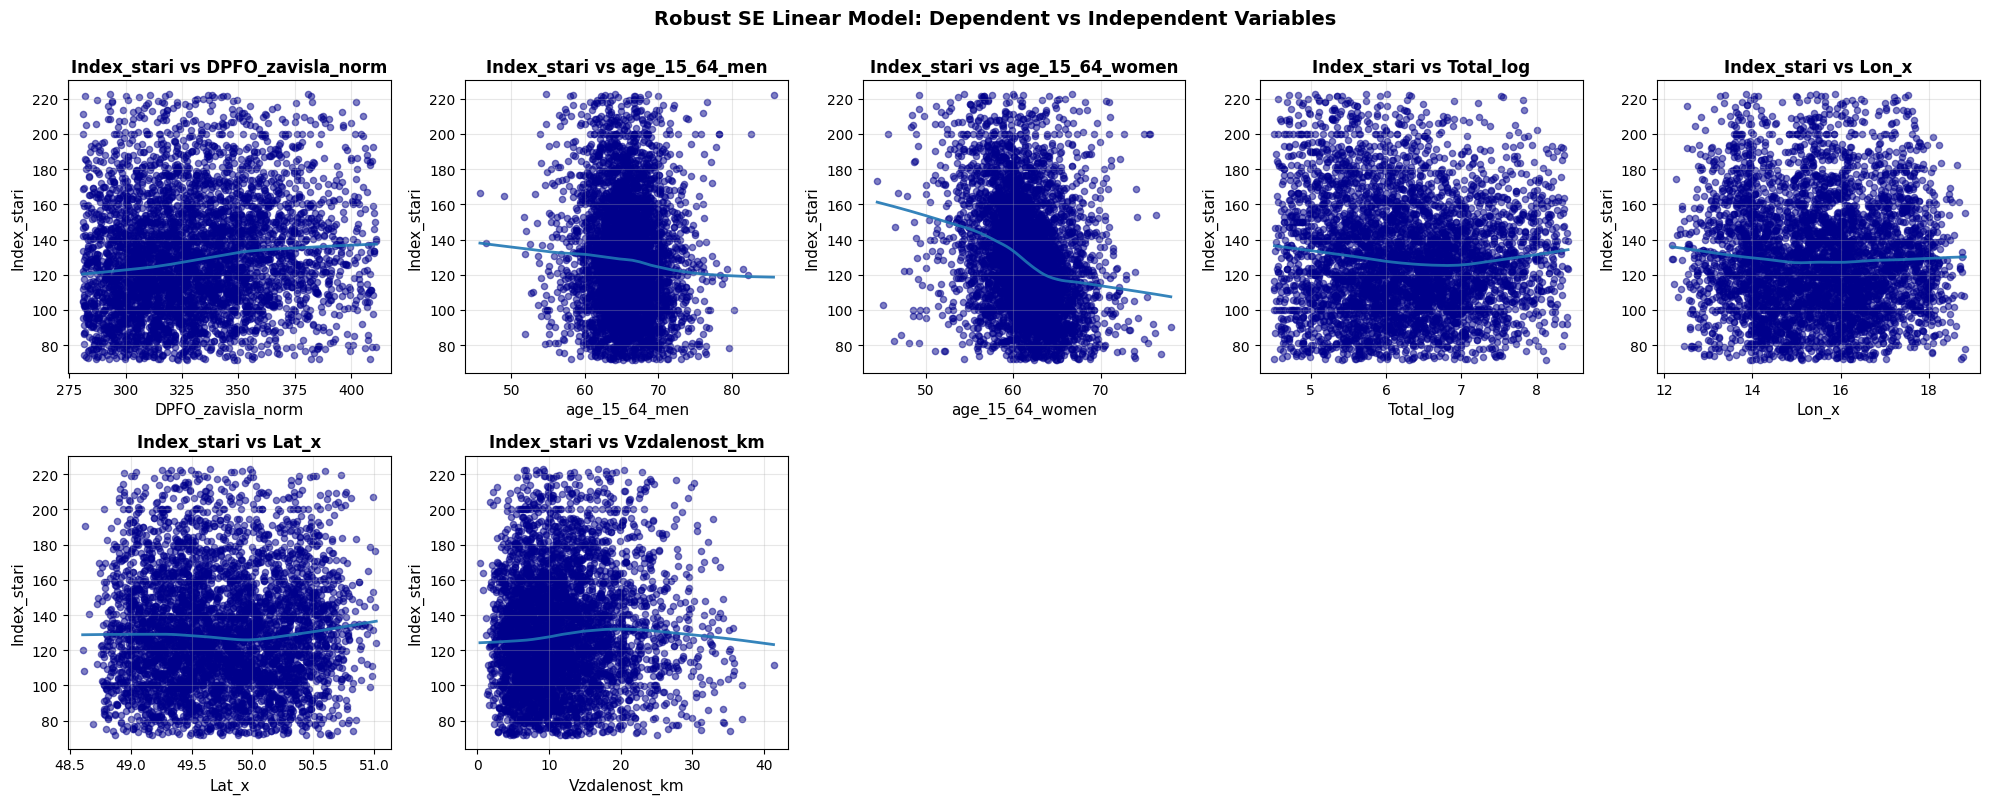

Interpretation:
  - LOWESS line shows the trend between each feature and target
  - Linear trend = good; curved pattern = potential non-linearity



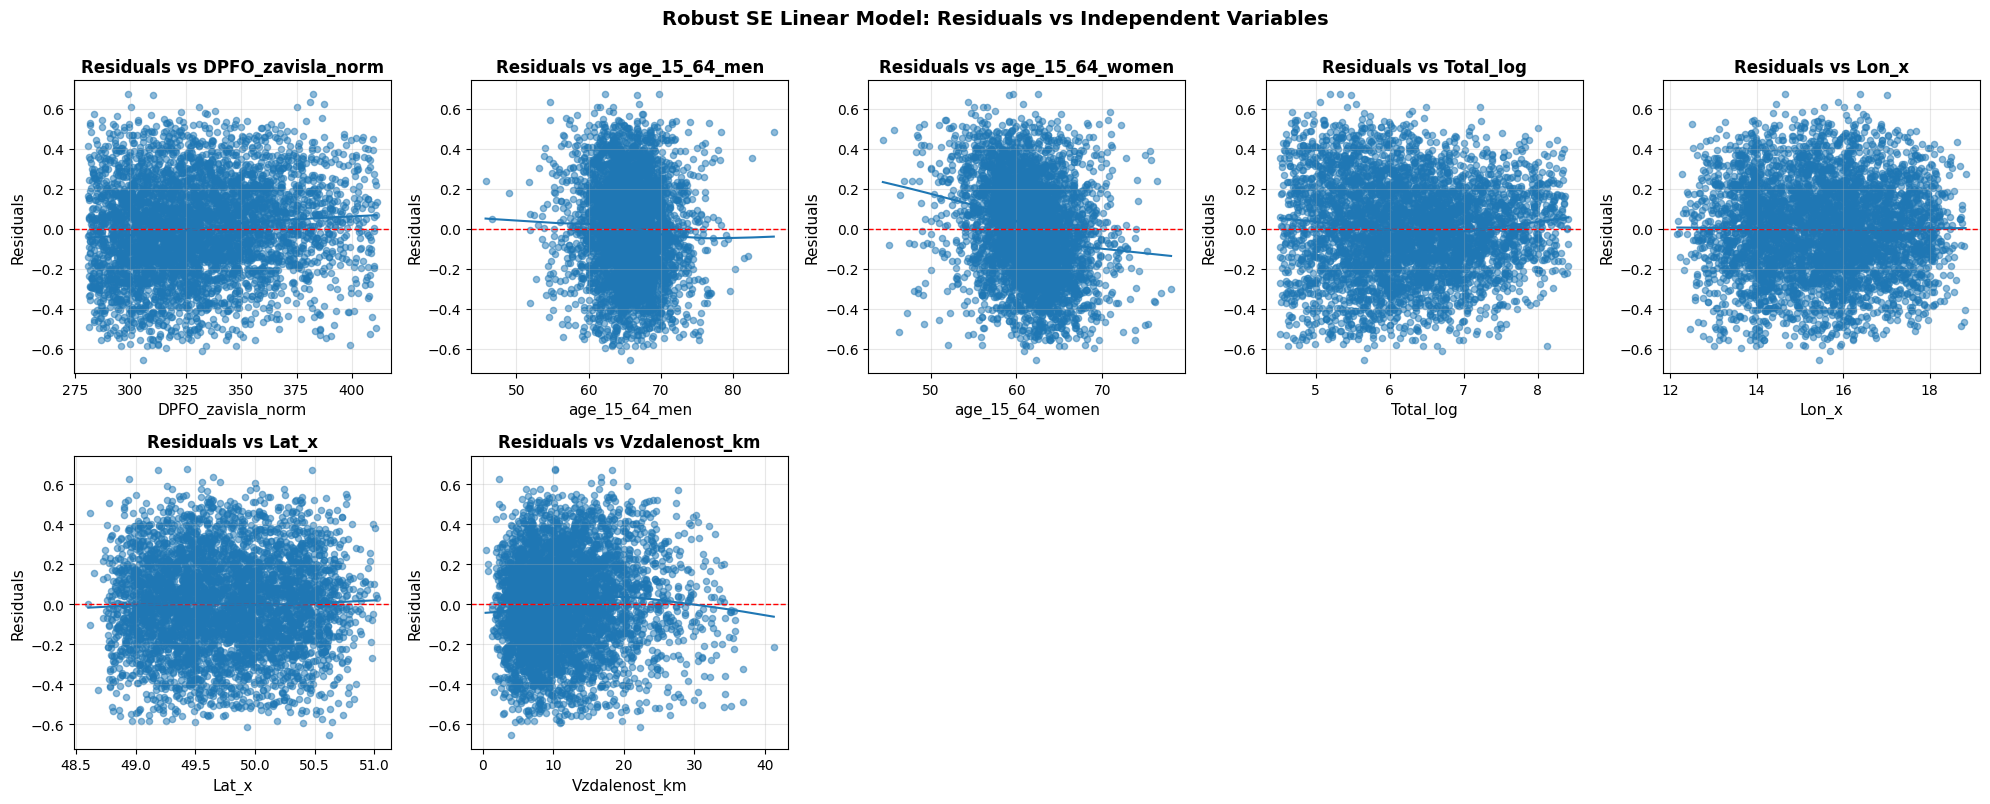

Interpretation:
  - Points should be randomly scattered around y=0; no patterns
  - Curves = non-linearity; funnel = heteroscedasticity
------------------------------------------------
TEST HOMOSCEDASTICITY
Breusch–Pagan LM p-value for Robust SE Linear Model: 0.000674 (LM stat=120.517)
------------------------------------------------
TEST INDEPENDENCE OF ERRORS
Durbin–Watson statistic for Robust SE Linear Model: 2.038
Ljung–Box test results for Robust SE Linear Model (lags [10, 20, 40]):
      lb_stat  lb_pvalue
10   9.413664   0.493346
20  14.280085   0.816016
40  40.827964   0.433908


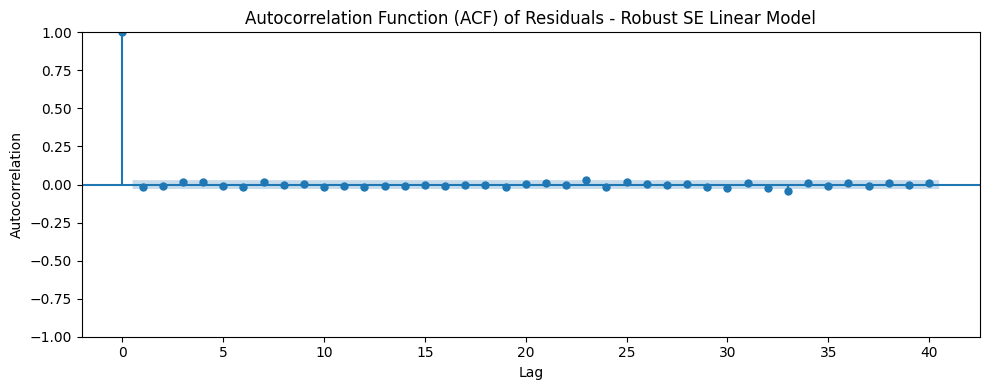

------------------------------------------------
TEST NORMALITY OF ERRORS


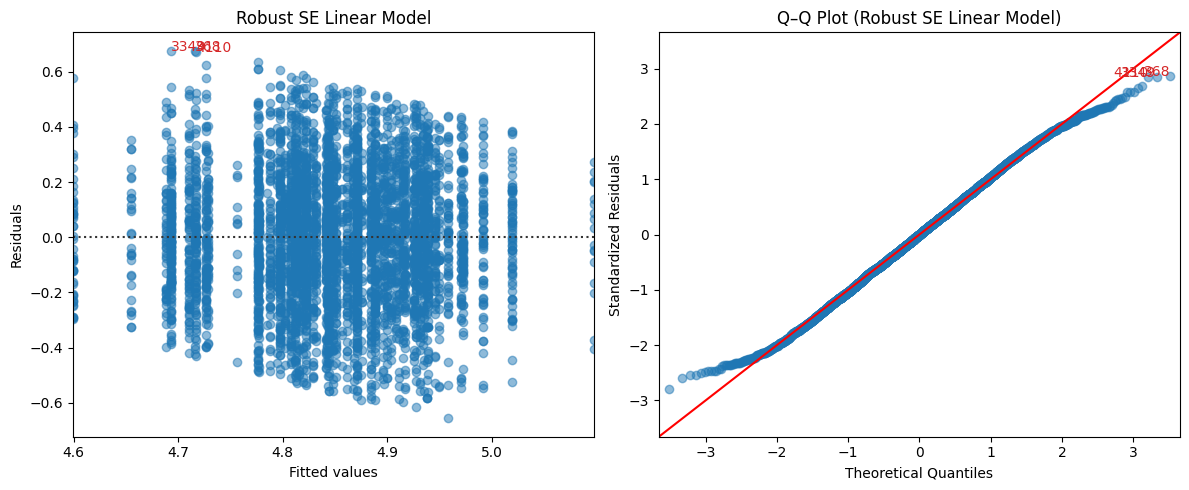

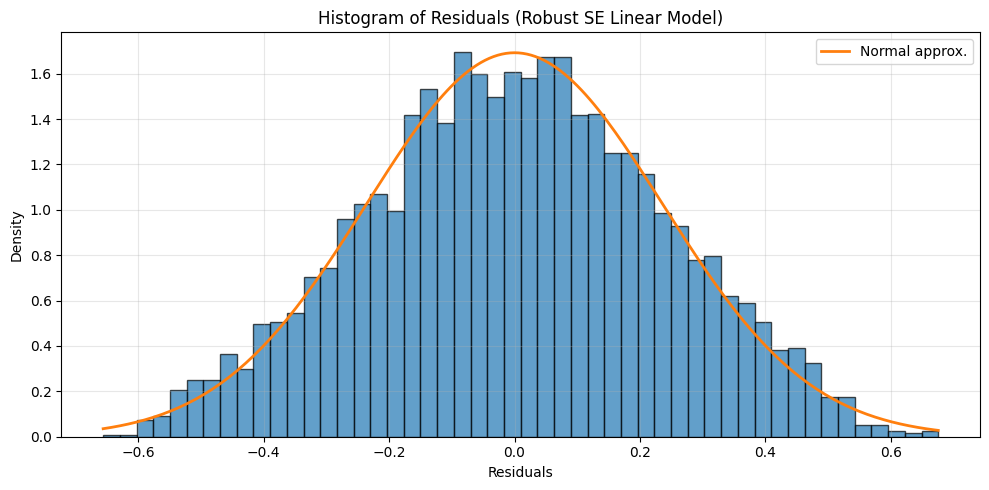

Shapiro–Wilk test for Robust SE Linear Model: W=0.9967, p-value=1.672e-08
------------------------------------------------
TEST MULTICOLLINEARITY


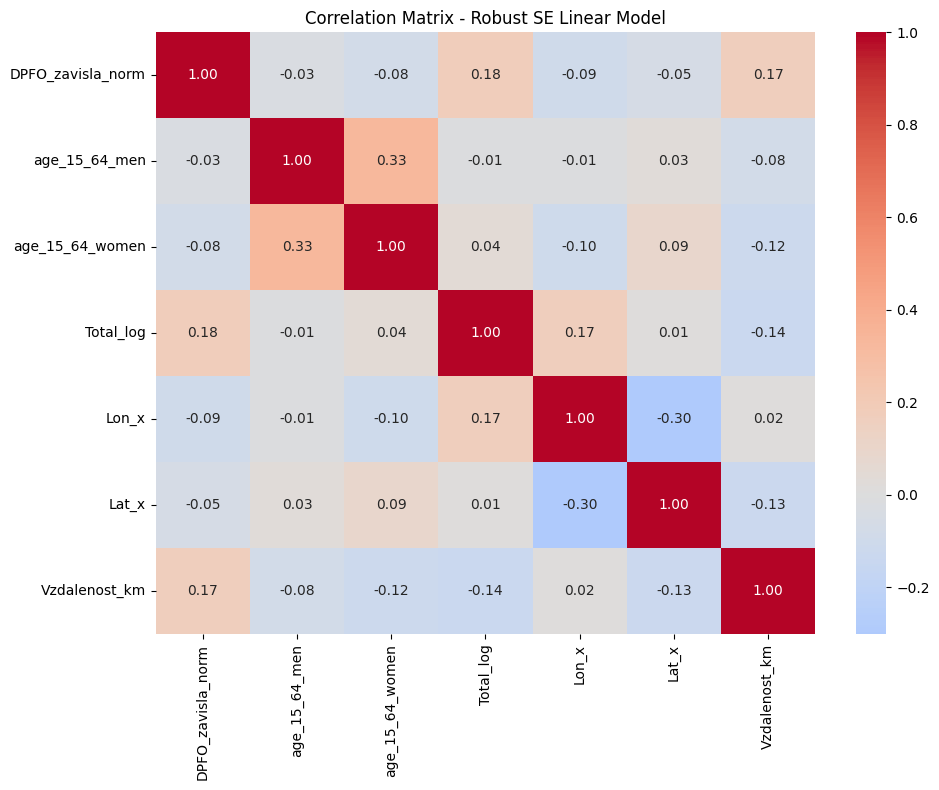

Variance Inflation Factor (VIF):
                                Features  VIF Factor
21           C(Okres_y)[T.Okres Karviná]        1.07
38     C(Okres_y)[T.Okres Ostrava-město]        1.13
42       C(Okres_y)[T.Okres Plzeň-město]        1.17
31              C(Okres_y)[T.Okres Most]        1.22
16           C(Okres_y)[T.Okres Jeseník]        1.24
..                                   ...         ...
67            C(Okres_y)[T.Okres Znojmo]        2.46
62            C(Okres_y)[T.Okres Třebíč]        2.72
74  C(Okres_y)[T.Okres Žďár nad Sázavou]        2.85
3        C(Okres_y)[T.Okres Brno-venkov]        2.93
0                              Intercept       64.80

[75 rows x 2 columns]
------------------------------------------------


In [43]:
# Řešení heteroscedacity: OLS s robustními standardními chybami (HC3)
# Robustní SE korigují heteroskedasticitu bez změny koeficientů

model_robust = smf.ols('Index_stari_log ~ ' + string_x, data=final_df).fit(cov_type='HC3')


perform_all_tests(model_robust, final_df, numeric_features, 'Robust SE Linear Model', y_col='Index_stari')


In [44]:
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:        Index_stari_log   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     8.277
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           2.96e-79
Time:                        17:59:00   Log-Likelihood:                 117.73
No. Observations:                4536   AIC:                            -85.46
Df Residuals:                    4461   BIC:                             396.0
Df Model:                          74                                         
Covariance Type:                  HC3                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

We used more robust (cov_type='HC3') standard errors to deal with Heteroscedacity and have all p-values reliable and not to care about the violation of this assumption. However, the coefficients remain the same as in OLS regression and the model performance metrics (R², RMSE) also remain the same. The model is pretty bad in terms of performance.

Lets try generalized linear model with Gaussian family and log link function.

Not overdispersed, we can use Poisson model.

In [45]:
# GAMMA GLM MODEL - stejné features jako OLS
# Gamma je lepší pro kladná spojitá data než Poisson

# Připravíme X (numerické + kategorické s one-hot encoding)
X_glm = final_df[numeric_features + categorical_features].copy()
X_glm = pd.get_dummies(X_glm, columns=categorical_features, drop_first=True, dtype=float)

print(f"Počet features: {X_glm.shape[1]}")

# Přidáme intercept
X_glm = sm.add_constant(X_glm)

# Y hodnoty - Gamma používá PŮVODNÍ hodnoty (model má built-in log link)
y_glm = final_df['Index_stari'].values

# Kontrola kladných hodnot
if (y_glm <= 0).any():
    print(f"⚠️ {(y_glm <= 0).sum()} nekladných hodnot - odstraňuji...")
    mask = y_glm > 0
    y_glm = y_glm[mask]
    X_glm = X_glm[mask]

print(f"Pozorování: {len(y_glm)}, Y range: [{y_glm.min():.2f}, {y_glm.max():.2f}]")

# Fit Gamma GLM
glm_gamma = sm.GLM(y_glm, X_glm, family=sm.families.Gamma(link=sm.families.links.Log()))
results_gamma = glm_gamma.fit()

print("\n" + "="*80)
print("GAMMA GLM MODEL")
print("="*80)
print(results_gamma.summary())

Počet features: 81
Pozorování: 4536, Y range: [71.70, 222.92]

GAMMA GLM MODEL
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 4536
Model:                            GLM   Df Residuals:                     4454
Model Family:                   Gamma   Df Model:                           81
Link Function:                    Log   Scale:                        0.053127
Method:                          IRLS   Log-Likelihood:                -21691.
Date:                Fri, 12 Dec 2025   Deviance:                       234.62
Time:                        17:59:00   Pearson chi2:                     237.
No. Iterations:                    12   Pseudo R-squ. (CS):             0.1899
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

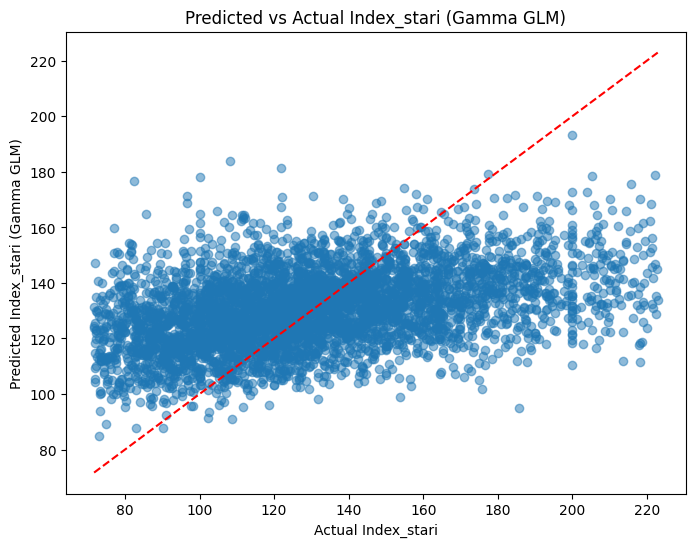

In [46]:
# Predikce a vizualizace
predictions_gamma = results_gamma.predict(X_glm)
#plot predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(final_df['Index_stari'], predictions_gamma, alpha=0.5)
plt.plot([final_df['Index_stari'].min(), final_df['Index_stari'].max()],
         [final_df['Index_stari'].min(), final_df['Index_stari'].max()], 'r--')
plt.xlabel('Actual Index_stari')
plt.ylabel('Predicted Index_stari (Gamma GLM)')
plt.title('Predicted vs Actual Index_stari (Gamma GLM)')
plt.show()

Lets try splines to capture non-linearity.


In [47]:
# fit spline model
# Použijeme stejné features jako předchozí modely
# Pro splines používáme cr() z patsy, který už máme importovaný

# Pro kategorickou proměnnou Okres_y použijeme C() wrapper
formula_spline = 'Index_stari_log ~ cr(DPFO_zavisla_norm, df=5) + cr(age_15_64_men, df=5)+cr(age_15_64_women, df=5) + cr(Total_log, df=5) + cr(Lon_x, df=5) + cr(Lat_x, df=5) + cr(Vzdalenost_km, df=5) + C(Okres_y)'

model_spline = smf.ols(formula_spline, data=final_df).fit()

print(model_spline.summary())

# Výpočet metriky R²
from sklearn.metrics import r2_score, mean_squared_error
predictions_spline = model_spline.predict(final_df)

# Inverse transform pro porovnání s původními hodnotami
predictions_spline_orig = np.expm1(predictions_spline)
y_true_orig = final_df['Index_stari'].values

r2 = r2_score(y_true_orig, predictions_spline_orig)
rmse = np.sqrt(mean_squared_error(y_true_orig, predictions_spline_orig))

print(f"\n{'='*80}")
print(f"Model Performance Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"{'='*80}")

# Interaktivní vizualizace predicted vs actual
fig = px.scatter(
    x=y_true_orig,
    y=predictions_spline_orig,
    hover_name=final_df['Nazev_obce_prijmy'],
    title='Spline Model: Predicted vs Actual Index_stari',
    labels={'x': 'Actual Index_stari', 'y': 'Predicted Index_stari'},
    opacity=0.6
)
fig.add_trace(
    go.Scatter(
        x=[y_true_orig.min(), y_true_orig.max()],
        y=[y_true_orig.min(), y_true_orig.max()],
        mode='lines',
        name='Ideální predikce',
        line=dict(color='red', width=3, dash='dash')
    )
)
fig.update_layout(width=900, height=700)
fig.show()

# Vizualizace nelineárních závislostí pro každou numerickou feature
numeric_features_to_plot = ["DPFO_zavisla_norm", "age_15_64_men", "age_15_64_women","Total_log",
                             "Lon_x", "Lat_x", "Vzdalenost_km"]

# Nejčastější okres pro konstantní hodnotu
most_common_okres = final_df['Okres_y'].mode()[0]

for feature in numeric_features_to_plot:
    print(f"\nGenerating plot for {feature}...")
    
    # Vytvoříme range hodnot pro danou feature
    x_range = np.linspace(final_df[feature].min(), final_df[feature].max(), 200)
    
    # Vytvoříme predikční dataframe - začneme s jednou řádkou a opakujeme ji
    pred_df = final_df.iloc[[0]].copy()  # Vezmeme první řádek jako šablonu
    pred_df = pd.concat([pred_df] * len(x_range), ignore_index=True)
    
    # Nastavíme proměnnou feature na x_range
    pred_df[feature] = x_range
    
    # Ostatní numerické features nastavíme na medián
    for col in numeric_features:
        if col != feature:
            pred_df[col] = final_df[col].median()
    
    # Okres_y nastavíme na nejčastější hodnotu
    pred_df['Okres_y'] = most_common_okres
    
    try:
        # Predikce
        y_pred_spline = model_spline.predict(pred_df)
        y_pred_spline_orig = np.expm1(y_pred_spline)
        
        # Interaktivní plot
        fig = px.scatter(
            final_df,
            x=feature,
            y='Index_stari',
            hover_name='Nazev_obce_prijmy',
            title=f'Nelineární závislost: Index_stari ~ {feature} (Spline Model)',
            opacity=0.5,
            labels={feature: feature, 'Index_stari': 'Index_stari'}
        )
        
        fig.add_trace(
            go.Scatter(
                x=x_range,
                y=y_pred_spline_orig,
                mode='lines',
                name=f'Spline Model (df=5)',
                line=dict(color='red', width=3)
            )
        )
        
        fig.update_layout(width=900, height=600)
        fig.show()
        
        print(f"✓ Plot for {feature} generated successfully")
        
    except Exception as e:
        print(f"✗ Error generating plot for {feature}: {str(e)}")
        continue

                            OLS Regression Results                            
Dep. Variable:        Index_stari_log   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     10.72
Date:                Fri, 12 Dec 2025   Prob (F-statistic):          4.07e-145
Time:                        17:59:01   Log-Likelihood:                 364.49
No. Observations:                4536   AIC:                            -523.0
Df Residuals:                    4433   BIC:                             138.3
Df Model:                         102                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------


Generating plot for DPFO_zavisla_norm...


✓ Plot for DPFO_zavisla_norm generated successfully

Generating plot for age_15_64_men...


✓ Plot for age_15_64_men generated successfully

Generating plot for age_15_64_women...


✓ Plot for age_15_64_women generated successfully

Generating plot for Total_log...


✓ Plot for Total_log generated successfully

Generating plot for Lon_x...


✓ Plot for Lon_x generated successfully

Generating plot for Lat_x...


✓ Plot for Lat_x generated successfully

Generating plot for Vzdalenost_km...


✓ Plot for Vzdalenost_km generated successfully


Lets try Random Forest Model


Random Forest Model Performance Metrics:
R² Score: 0.1151
RMSE: 30.9516


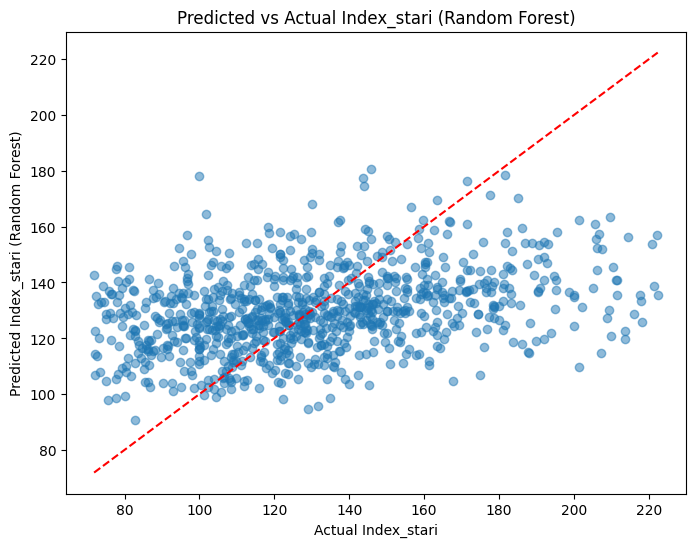

In [48]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Prepare features and target randomly choose 80% train and 20% test
from sklearn.model_selection import train_test_split
X = final_df[numeric_features + categorical_features].copy()
X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=float)
y = final_df['Index_stari'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
# Evaluate
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"\n{'='*80}")
print(f"Random Forest Model Performance Metrics:")
print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"{'='*80}")  

#plot predicted vs actual for RF
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Index_stari')
plt.ylabel('Predicted Index_stari (Random Forest)')
plt.title('Predicted vs Actual Index_stari (Random Forest)')
plt.show()

Lets train NN

In [49]:
import torch 
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Prepare data for NN
X_nn = final_df[numeric_features + categorical_features].copy()
X_nn = pd.get_dummies(X_nn, columns=categorical_features, drop_first=True, dtype=float)
y_nn = final_df['Index_stari'].values   
# Convert to tensors
X_tensor = torch.tensor(X_nn.values, dtype=torch.float32)
y_tensor = torch.tensor(y_nn, dtype=torch.float32).view(-1, 1)  
# Train-test split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)
# Create DataLoaders
train_dataset = TensorDataset(X_train_nn, y_train_nn)
test_dataset = TensorDataset(X_test_nn, y_test_nn)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# Define NN model
class SimpleNN(nn.Module):  
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        backbone = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
        )
        self.fc1 = backbone
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)
    def forward(self, x):
        feature = self.relu(self.fc1(x))
        feature = self.relu(self.fc2(feature))
        return feature, feature
# Initialize model, loss function, optimizer
input_dim = X_nn.shape[1]
model_nn = SimpleNN(input_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)
# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    model_nn.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs, _ = model_nn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
# Evaluation
model_nn.eval()
with torch.no_grad():
    y_pred_nn = []
    for X_batch, _ in test_loader:
        outputs, _ = model_nn(X_batch)
        y_pred_nn.append(outputs)
    y_pred_nn = torch.cat(y_pred_nn, dim=0).numpy()
# Evaluate
r2_nn = r2_score(y_test_nn.numpy(), y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test_nn.numpy(), y_pred_nn))
print(f"\n{'='*80}")
print(f"Neural Network Model Performance Metrics:")
print(f"R² Score: {r2_nn:.4f}")
print(f"RMSE: {rmse_nn:.4f}")
print(f"{'='*80}")  

Epoch [10/500], Loss: 7415.4321
Epoch [20/500], Loss: 1132.9603
Epoch [30/500], Loss: 1058.0353
Epoch [40/500], Loss: 579.7134
Epoch [50/500], Loss: 830.8499
Epoch [60/500], Loss: 528.9792
Epoch [70/500], Loss: 904.2468
Epoch [80/500], Loss: 427.1912
Epoch [90/500], Loss: 746.1745
Epoch [100/500], Loss: 1169.5427
Epoch [110/500], Loss: 840.0972
Epoch [120/500], Loss: 1077.2039
Epoch [130/500], Loss: 713.6091
Epoch [140/500], Loss: 566.7877
Epoch [150/500], Loss: 977.4214
Epoch [160/500], Loss: 1804.4435
Epoch [170/500], Loss: 483.7115
Epoch [180/500], Loss: 877.9584
Epoch [190/500], Loss: 1084.4473
Epoch [200/500], Loss: 405.3725
Epoch [210/500], Loss: 714.7571
Epoch [220/500], Loss: 353.0061
Epoch [230/500], Loss: 250.3783
Epoch [240/500], Loss: 1029.0581
Epoch [250/500], Loss: 552.7332
Epoch [260/500], Loss: 828.7408
Epoch [270/500], Loss: 731.0353
Epoch [280/500], Loss: 1839.5693
Epoch [290/500], Loss: 429.1723
Epoch [300/500], Loss: 624.3406
Epoch [310/500], Loss: 1630.0721
Epoch [

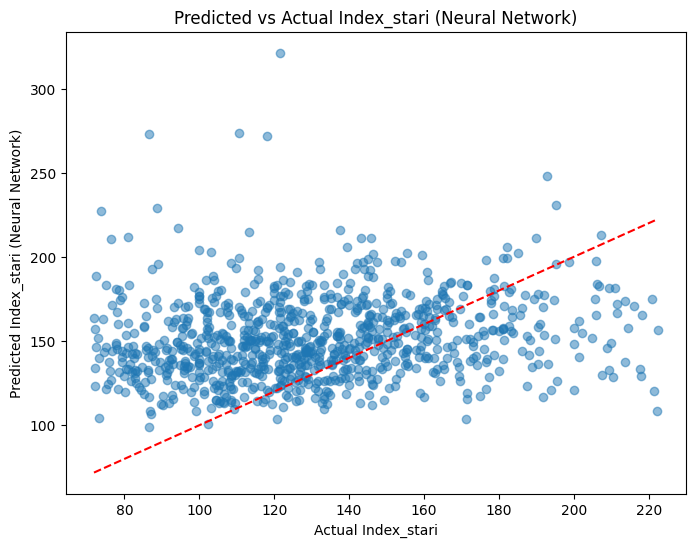

In [50]:
# Predikce a vizualizace
#plot predicted vs actual for NN
plt.figure(figsize=(8, 6))
plt.scatter(y_test_nn.numpy(), y_pred_nn, alpha=0.5)
plt.plot([y_test_nn.numpy().min(), y_test_nn.numpy().max()],
         [y_test_nn.numpy().min(), y_test_nn.numpy().max()], 'r--')
plt.xlabel('Actual Index_stari')
plt.ylabel('Predicted Index_stari (Neural Network)')
plt.title('Predicted vs Actual Index_stari (Neural Network)')
plt.show()  

In [53]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import RFE

# Prepare data
X = pd.get_dummies(final_df[numeric_features + categorical_features], 
                   columns=categorical_features, drop_first=True)
y = final_df['Index_stari'].values

# Feature selection
gbm = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
selector = RFE(gbm, n_features_to_select=10, step=1)
selector.fit(X, y)

# Show selected features
selected_features = X.columns[selector.support_]
print(f"Selected features: {selected_features.tolist()}")

# Refit with selected features
X_selected = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)

r2_gbm = r2_score(y_test, y_pred_gbm)
print(f"GBM R²: {r2_gbm:.4f}")

Selected features: ['DPFO_zavisla_norm', 'age_15_64_men', 'age_15_64_women', 'Total_log', 'Lon_x', 'Lat_x', 'Vzdalenost_km', 'Okres_y_Okres Brno-venkov', 'Okres_y_Okres Hodonín', 'Okres_y_Okres Písek']
GBM R²: 0.1265


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cities_df = df.copy()

# Perform clustering based on Index_stari
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cities_df[['Index_stari']])
number_of_clusters = 10
kmeans = KMeans(n_clusters=number_of_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Sort clusters by their center values (lowest to highest)
cluster_centers = kmeans.cluster_centers_.flatten()
cluster_order = np.argsort(cluster_centers)
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_order)}
cities_df['cluster_age'] = np.array([cluster_mapping[label] for label in cluster_labels])

# Plot clusters in 3D scatter plot with cluster labels on Z axis
fig = go.Figure(data=[go.Scatter3d(
    x=cities_df['Lon_x'],
    y=cities_df['Lat_x'],
    z=cities_df['cluster_age'],  # Use cluster labels instead of raw values
    mode='markers',
    marker=dict(
        size=2,
        color=cities_df['cluster_age'],  # set color to cluster
        colorscale='Jet',  # choose a colorscale
        opacity=0.8
    ),
    hovertext=cities_df['Nazev_obce_prijmy'] + '<br>Index_stari: ' + cities_df['Index_stari'].astype(str)
)])
fig.update_layout(
    scene = dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Age Cluster',
        xaxis=dict(autorange='reversed'),
        yaxis=dict(autorange='reversed')
    ),
    title='3D Scatter Plot of Cities by Age Index Clusters'
)
fig.show()

NameError: name 'cities_df' is not defined